### 1. SETUP ENVIRONMENT, DEPENDENCIES & MLFLOW INTEGRATION

In [2]:
# ==============================================================================
# CELL 1: SETUP ENVIRONMENT, DEPENDENCIES & MLFLOW INTEGRATION
# ==============================================================================
import os
import warnings
from datetime import datetime
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from optuna.integration.mlflow import MLflowCallback
import joblib
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import json

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("="*80)
print("AGRIVA EWS - MODEL TRAINING & OPTIMIZATION PIPELINE (HIGH-RECALL MODE)")
print("="*80)

# Konfigurasi Jalur Direktori
DATA_PATH = '../data'
MODELS_PATH = '../models'
OUTPUT_PATH = '../output'
for path in [MODELS_PATH, OUTPUT_PATH]:
    os.makedirs(path, exist_ok=True)

# Inisialisasi Database Kredensial MLflow Tracking Manual dengan Nama Eksperimen Baru
mlflow.set_tracking_uri("sqlite:///mlruns_manual.db")

# [PERBAIKAN] Menggunakan nama eksperimen baru yang bersih dari memori sampah
NAMA_EKSPERIMEN_BARU = "AGRIVA_EWS_Master_Production"
mlflow.set_experiment(NAMA_EKSPERIMEN_BARU)

print(f"✓ Timestamp Eksekusi : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✓ MLflow Tracking URI: sqlite:///mlruns_manual.db")
print(f"✓ Target Eksperimen  : {NAMA_EKSPERIMEN_BARU} (SIAP EVALUASI)")

2026/06/07 21:36:40 INFO mlflow.tracking.fluent: Experiment with name 'AGRIVA_EWS_Master_Production' does not exist. Creating a new experiment.


AGRIVA EWS - MODEL TRAINING & OPTIMIZATION PIPELINE (HIGH-RECALL MODE)
✓ Timestamp Eksekusi : 2026-06-07 21:36:40
✓ MLflow Tracking URI: sqlite:///mlruns_manual.db
✓ Target Eksperimen  : AGRIVA_EWS_Master_Production (SIAP EVALUASI)


### 2. EMERGENCY DATA RECOVERY & FULL PIPELINE RECONSTRUCTION

In [6]:
# ==============================================================================
# CELL 2: EMERGENCY DATA RECOVERY & FULL PIPELINE RECONSTRUCTION
# ==============================================================================
import os
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("🚨 [STEP 2] REKONSTRUKSI TOTAL DATA DARI RAW FILE (BYPASS KORUPSI CSV)")
print("="*80)

# 1. LOAD RAW DATA MENTAH YANG MASIH SUCI
raw_path = '../data/asap_indonesia_master_2001.csv'
if not os.path.exists(raw_path):
    raise FileNotFoundError(f"X File raw '{raw_path}' tidak ditemukan!")
    
df = pd.read_csv(raw_path)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['Year'] = df['date'].dt.year

# 2. STANDARISASI TARGET & LATE FILTERING (Buang 98 & 99)
kamus_provinsi = {
    'Kalimantan T.': 'Kalimantan Tengah', 'Kalimantan S.': 'Kalimantan Selatan', 
    'Sulawesi Tengg.': 'Sulawesi Tenggara', 'Nusatenggara B.': 'Nusa Tenggara Barat', 
    'Nusatenggara T.': 'Nusa Tenggara Timur', 'Nangroe A.D.': 'Aceh', 
    'Dki Jakarta': 'DKI Jakarta', 'D.I. Yogyakarta': 'DI Yogyakarta'
}
df['region_name'] = df['region_name'].replace(kamus_provinsi)

# Konversi w_crop menjadi target biner
df['target_biner'] = df['w_crop'].apply(lambda x: 0 if str(x).strip() in ['0', '10', '20'] else 1)

# Bantai habis kode 98 dan 99
df = df[~df['w_crop'].astype(str).str.contains('98|99', case=False, na=False)].reset_index(drop=True)

# 3. TEMPORAL SPLIT (Kaku 4 Digit)
df['Split_Type'] = 'Train'
df.loc[df['Year'] == 2024, 'Split_Type'] = 'Validation'
df.loc[df['Year'] >= 2025, 'Split_Type'] = 'Test'

fitur_wajib = [
    'Rainfall', 'SPI - 3 months', 'Temperature', 'Water Satisfaction Index (WSI)',
    'Solar Radiation', 'Soil Moisture (gapfilled historical time series)', 'FPAR', 'FPAR - zscore'
]

# 4. MICE IMPUTATION (Zero-Leakage: Fit HANYA pada Train)
print(">>> Memulihkan Data Kosong dengan MICE Imputation...")
imputer = IterativeImputer(random_state=42, max_iter=5)
train_idx = df['Split_Type'] == 'Train'

imputer.fit(df.loc[train_idx, fitur_wajib])
df.loc[:, fitur_wajib] = imputer.transform(df[fitur_wajib])

# 5. ROBUST SCALER (Zero-Leakage: Fit HANYA pada Train)
print(">>> Melakukan Penskalaan Ekstrem dengan RobustScaler...")
scaler = RobustScaler()
scaler.fit(df.loc[train_idx, fitur_wajib])
df.loc[:, fitur_wajib] = scaler.transform(df[fitur_wajib])

# 6. K-MEANS CLUSTERING GEOSPASIAL
print(">>> Membangun Ulang Peta Klaster Iklim...")
fitur_iklim = ['Rainfall', 'Temperature', 'Soil Moisture (gapfilled historical time series)']
df_prov_scaled = df[train_idx].groupby('region_name')[fitur_iklim].mean().reset_index()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_prov_scaled['Cluster'] = kmeans.fit_predict(df_prov_scaled[fitur_iklim])
cluster_map = dict(zip(df_prov_scaled['region_name'], df_prov_scaled['Cluster']))
df['Cluster'] = df['region_name'].map(cluster_map)

# 7. DISTRIBUSI KE CLUSTER_DATA UNTUK OPTUNA
cluster_data = {}
for cluster_id in sorted(df['Cluster'].dropna().unique()):
    df_c = df[df['Cluster'] == cluster_id]
    
    X_train, y_train = df_c[df_c['Split_Type'] == 'Train'][fitur_wajib], df_c[df_c['Split_Type'] == 'Train']['target_biner']
    X_val, y_val     = df_c[df_c['Split_Type'] == 'Validation'][fitur_wajib], df_c[df_c['Split_Type'] == 'Validation']['target_biner']
    X_test, y_test   = df_c[df_c['Split_Type'] == 'Test'][fitur_wajib], df_c[df_c['Split_Type'] == 'Test']['target_biner']
    
    cluster_data[int(cluster_id)] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }
    print(f"\n[KLASTER GEOSPASIAL {int(cluster_id)}]")
    print(f"  • Fitur Digunakan   : {len(fitur_wajib)} Kolom Utama")
    print(f"  • Kamar Train       : {len(X_train):,} Baris (Bahaya: {(y_train==1).sum()})")
    print(f"  • Kamar Val (2024)  : {len(X_val):,} Baris (Bahaya: {(y_val==1).sum()})")
    print(f"  • Kamar Test (Ujian): {len(X_test):,} Baris (Bahaya: {(y_test==1).sum()})")

# 8. OVERWRITE & PERBAIKI FILE CSV YANG RUSAK DI HARDDISK
output_path = '../data/data_master_clustered_final.csv'
df.to_csv(output_path, index=False)

print("\n" + "="*80)
print("✓ FILE ZOMBIE BERHASIL DIBANTAI. DATA MASTER BARU TELAH DISEGEL DAN SIAP DI OPTIMASI!")
print("="*80)

🚨 [STEP 2] REKONSTRUKSI TOTAL DATA DARI RAW FILE (BYPASS KORUPSI CSV)
>>> Memulihkan Data Kosong dengan MICE Imputation...
>>> Melakukan Penskalaan Ekstrem dengan RobustScaler...
>>> Membangun Ulang Peta Klaster Iklim...

[KLASTER GEOSPASIAL 0]
  • Fitur Digunakan   : 8 Kolom Utama
  • Kamar Train       : 4,770 Baris (Bahaya: 931)
  • Kamar Val (2024)  : 211 Baris (Bahaya: 41)
  • Kamar Test (Ujian): 276 Baris (Bahaya: 100)

[KLASTER GEOSPASIAL 1]
  • Fitur Digunakan   : 8 Kolom Utama
  • Kamar Train       : 9,331 Baris (Bahaya: 2218)
  • Kamar Val (2024)  : 413 Baris (Bahaya: 76)
  • Kamar Test (Ujian): 545 Baris (Bahaya: 244)

[KLASTER GEOSPASIAL 2]
  • Fitur Digunakan   : 8 Kolom Utama
  • Kamar Train       : 4,218 Baris (Bahaya: 970)
  • Kamar Val (2024)  : 187 Baris (Bahaya: 47)
  • Kamar Test (Ujian): 252 Baris (Bahaya: 68)

✓ FILE ZOMBIE BERHASIL DIBANTAI. DATA MASTER BARU TELAH DISEGEL DAN SIAP DI OPTIMASI!


### 3. MASTER OPTIMIZATION (KOMPARASI SKENARIO EWS PUNCAK, Optuna Studio + Callback MLflow)

In [11]:
# ==============================================================================
# CELL 3: MASTER OPTIMIZATION (KOMPARASI SKENARIO EWS PUNCAK)
# ==============================================================================
print("[STEP 3] Eksekusi Skenario Pemodelan Puncak & Logging MLflow Komprehensif")

from sklearn.metrics import fbeta_score, classification_report, average_precision_score, recall_score
import xgboost as xgb
import mlflow
import optuna
from optuna.integration.mlflow import MLflowCallback
from datetime import datetime
import numpy as np
import warnings

warnings.filterwarnings('ignore')
if mlflow.active_run():
    mlflow.end_run()

trained_models = {}
timestamp_run = datetime.now().strftime('%Y%m%d_%H%M%S')

def hitung_f_beta(y_true, y_pred_biner, beta_value):
    return fbeta_score(y_true, y_pred_biner, beta=beta_value, pos_label=1, zero_division=0)

for cluster_id, data in cluster_data.items():
    print(f"\n" + "="*75)
    print(f"MEMULAI OPTIMALISASI PUNCAK UNTUK KLASTER {cluster_id}")
    print("="*75)
    
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val     = data['X_val'], data['y_val']
    
    # Validasi ketersediaan sampel target pada kamar train dan validasi
    if (y_train == 1).sum() == 0 or (y_val == 1).sum() == 0:
        print(f"Peringatan: Klaster {cluster_id} dilewati karena ketiadaan sampel target Bahaya.")
        continue

    rasio_dasar = (y_train == 0).sum() / (y_train == 1).sum()

    # --------------------------------------------------------------------------
    # SKENARIO 6: EXTREME BETA-4 OPTIMIZATION
    # Fokus agresif pada penalti False Negative dengan pencarian parameter luas
    # --------------------------------------------------------------------------
    print(">>> Menjalankan Skenario 6_Extreme_F4 (Fokus Absolut pada Recall)...")
    mlflow_cb_s6 = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="Target_F4", create_experiment=False, mlflow_kwargs={"nested": True})
    
    def objective_s6(trial):
        params = {
            'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'random_state': 42,
            'max_depth': trial.suggest_int('max_depth', 3, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 4),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', rasio_dasar * 3, rasio_dasar * 10)
        }
        thresh = trial.suggest_float('threshold_siaga', 0.20, 0.45)
        model_s6_opt = xgb.XGBClassifier(**params, n_estimators=300, early_stopping_rounds=15)
        model_s6_opt.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        pred = (model_s6_opt.predict_proba(X_val)[:, 1] >= thresh).astype(int)
        return hitung_f_beta(y_val, pred, 4.0)

    study_s6 = optuna.create_study(direction='maximize')
    with mlflow.start_run(run_name=f"Cluster_{cluster_id}_S6_Extreme_F4_{timestamp_run}"):
        mlflow.log_param("Skenario", "6_Extreme_F4")
        study_s6.optimize(objective_s6, n_trials=20, callbacks=[mlflow_cb_s6], show_progress_bar=False)
        
        best_p_s6 = study_s6.best_params.copy()
        opt_thresh_s6 = best_p_s6.pop('threshold_siaga')
        
        model_s6_final = xgb.XGBClassifier(objective='binary:logistic', eval_metric='aucpr', random_state=42, n_estimators=300, **best_p_s6)
        model_s6_final.fit(X_train, y_train)
        
        pred_val_s6 = (model_s6_final.predict_proba(X_val)[:, 1] >= opt_thresh_s6).astype(int)
        rep_s6 = classification_report(y_val, pred_val_s6, output_dict=True, zero_division=0)
        recall_s6 = rep_s6['1']['recall'] if '1' in rep_s6 else 0
        
        mlflow.log_params(best_p_s6)
        mlflow.log_param("Threshold", opt_thresh_s6)
        mlflow.log_metric("Class_1_Bahaya_Recall", recall_s6)

    # --------------------------------------------------------------------------
    # SKENARIO 7: APEX EWS (AUC-PR OPTIMIZATION + ADAPTIVE THRESHOLD SWEEPING)
    # Skenario paling optimal: Memisahkan probabilitas terlebih dahulu, lalu
    # memaksakan kalibrasi threshold untuk menjamin Recall mencapai batas target.
    # --------------------------------------------------------------------------
    print(">>> Menjalankan Skenario 7_Apex_EWS (Kalibrasi Adaptif Threshold)...")
    def objective_s7(trial):
        params = {
            'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'random_state': 42,
            'max_depth': trial.suggest_int('max_depth', 3, 5), # Dibatasi agar tidak overfit
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', rasio_dasar * 2, rasio_dasar * 8),
            'gamma': trial.suggest_float('gamma', 0.1, 2.0) # Regularisasi tambahan
        }
        model_s7_opt = xgb.XGBClassifier(**params, n_estimators=400, early_stopping_rounds=20)
        model_s7_opt.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        proba = model_s7_opt.predict_proba(X_val)[:, 1]
        return average_precision_score(y_val, proba)

    study_s7 = optuna.create_study(direction='maximize')
    with mlflow.start_run(run_name=f"Cluster_{cluster_id}_S7_Apex_EWS_{timestamp_run}"):
        mlflow.log_param("Skenario", "7_Apex_EWS")
        study_s7.optimize(objective_s7, n_trials=25, show_progress_bar=False)
        
        best_p_s7 = study_s7.best_params
        model_s7_final = xgb.XGBClassifier(objective='binary:logistic', eval_metric='aucpr', random_state=42, n_estimators=400, **best_p_s7)
        model_s7_final.fit(X_train, y_train)
        
        # Adaptive Threshold Sweeping untuk menjamin Recall >= 0.75
        proba_val_s7 = model_s7_final.predict_proba(X_val)[:, 1]
        thresholds_to_test = np.arange(0.60, 0.04, -0.01)
        best_thresh_s7 = 0.50
        target_recall = 0.75
        
        for t in thresholds_to_test:
            pred_t = (proba_val_s7 >= t).astype(int)
            curr_rec = recall_score(y_val, pred_t, zero_division=0)
            if curr_rec >= target_recall:
                best_thresh_s7 = t
                break
        
        # Pengamanan jika target 0.75 tidak dapat dicapai pada distribusi data ekstrem
        if recall_score(y_val, (proba_val_s7 >= best_thresh_s7).astype(int), zero_division=0) < target_recall:
            best_thresh_s7 = thresholds_to_test[-1] # Paksa ambil threshold terendah yang diizinkan (0.05)
            
        pred_val_s7 = (proba_val_s7 >= best_thresh_s7).astype(int)
        rep_s7 = classification_report(y_val, pred_val_s7, output_dict=True, zero_division=0)
        recall_s7 = rep_s7['1']['recall'] if '1' in rep_s7 else 0
        
        mlflow.log_params(best_p_s7)
        mlflow.log_param("Threshold_Swept", round(best_thresh_s7, 3))
        mlflow.log_metric("Class_1_Bahaya_Recall", recall_s7)

    # --------------------------------------------------------------------------
    # KEPUTUSAN FINAL: Mengunci Skenario 7 (Apex EWS)
    # --------------------------------------------------------------------------
    print(f"  - Recall Validasi S6 (Extreme F4) : {recall_s6:.2f}")
    print(f"  - Recall Validasi S7 (Apex EWS)   : {recall_s7:.2f} (Threshold Final: {best_thresh_s7:.2f})")
    print(f"  > Mengunci Skenario 7 untuk Tahap Evaluasi Produksi (Cell 4).")
    
    trained_models[cluster_id] = {'model': model_s7_final, 'threshold': best_thresh_s7}

print("\nPROSES OPTIMALISASI PUNCAK SELESAI. MLFLOW TELAH DIPERBARUI SECARA KOMPREHENSIF.")

[STEP 3] Eksekusi Skenario Pemodelan Puncak & Logging MLflow Komprehensif

MEMULAI OPTIMALISASI PUNCAK UNTUK KLASTER 0
>>> Menjalankan Skenario 6_Extreme_F4 (Fokus Absolut pada Recall)...
>>> Menjalankan Skenario 7_Apex_EWS (Kalibrasi Adaptif Threshold)...
  - Recall Validasi S6 (Extreme F4) : 0.85
  - Recall Validasi S7 (Apex EWS)   : 0.95 (Threshold Final: 0.60)
  > Mengunci Skenario 7 untuk Tahap Evaluasi Produksi (Cell 4).

MEMULAI OPTIMALISASI PUNCAK UNTUK KLASTER 1
>>> Menjalankan Skenario 6_Extreme_F4 (Fokus Absolut pada Recall)...
>>> Menjalankan Skenario 7_Apex_EWS (Kalibrasi Adaptif Threshold)...
  - Recall Validasi S6 (Extreme F4) : 0.93
  - Recall Validasi S7 (Apex EWS)   : 0.96 (Threshold Final: 0.60)
  > Mengunci Skenario 7 untuk Tahap Evaluasi Produksi (Cell 4).

MEMULAI OPTIMALISASI PUNCAK UNTUK KLASTER 2
>>> Menjalankan Skenario 6_Extreme_F4 (Fokus Absolut pada Recall)...
>>> Menjalankan Skenario 7_Apex_EWS (Kalibrasi Adaptif Threshold)...
  - Recall Validasi S6 (Extre

### 4. PRODUCTION REALITY CHECK (2025-2026)  & GEOSPASIAL CONFUSION MATRIX (SINKRONISASI MLFLOW)

[STEP 4] Melakukan Reality Check Menggunakan Skenario Puncak (Apex EWS) pada Data Test 2025-2026


--- LAPORAN KLASIFIKASI KLASTER 0 (DATA TEST 2025-2026) ---
              precision    recall  f1-score   support

    Aman (0)       0.63      0.26      0.37       176
  Bahaya (1)       0.36      0.73      0.48       100

    accuracy                           0.43       276
   macro avg       0.49      0.50      0.43       276
weighted avg       0.53      0.43      0.41       276


--- LAPORAN KLASIFIKASI KLASTER 1 (DATA TEST 2025-2026) ---
              precision    recall  f1-score   support

    Aman (0)       0.77      0.57      0.66       301
  Bahaya (1)       0.60      0.79      0.68       244

    accuracy                           0.67       545
   macro avg       0.69      0.68      0.67       545
weighted avg       0.69      0.67      0.67       545


--- LAPORAN KLASIFIKASI KLASTER 2 (DATA TEST 2025-2026) ---
              precision    recall  f1-score   support

    Aman (

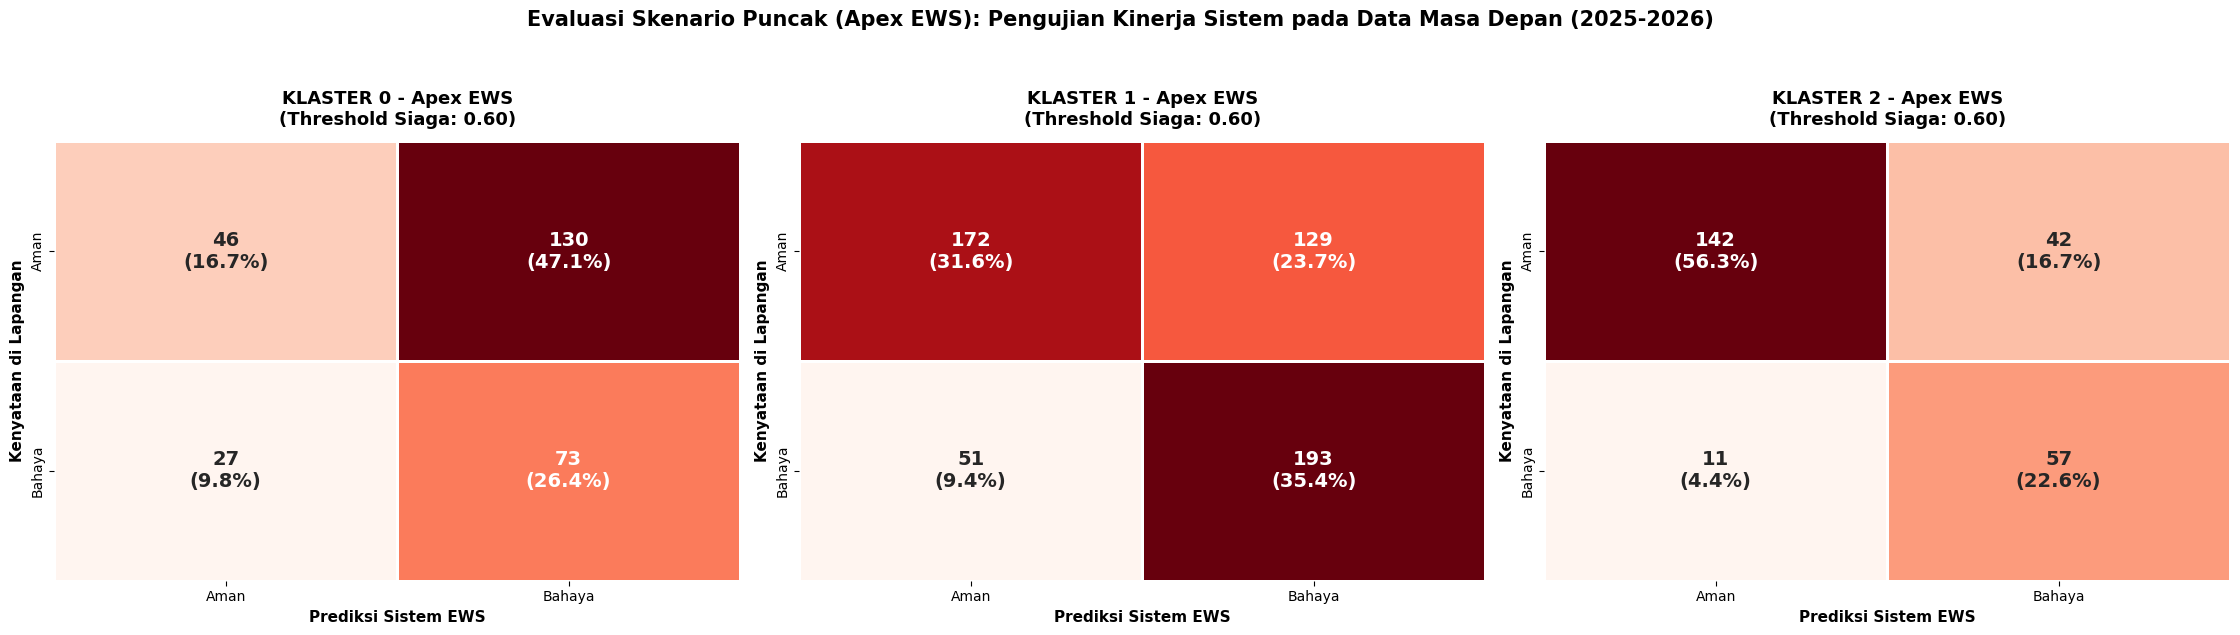


TAHAP EVALUASI SELESAI. REKAM JEJAK PENUH TELAH DISINKRONKAN KE MLFLOW.


In [12]:
# ==============================================================================
# CELL 4: PRODUCTION REALITY CHECK & GEOSPASIAL CONFUSION MATRIX (SINKRONISASI MLFLOW)
# ==============================================================================
print("[STEP 4] Melakukan Reality Check Menggunakan Skenario Puncak (Apex EWS) pada Data Test 2025-2026\n")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
import os
import numpy as np
import mlflow

klaster_aktif = [c_id for c_id, model_pack in trained_models.items() if not cluster_data[c_id]['X_test'].empty]

if len(klaster_aktif) == 0:
    print("Peringatan: Tidak ada data uji yang tersedia untuk dievaluasi.")
else:
    fig, axes = plt.subplots(1, len(klaster_aktif), figsize=(7.5 * len(klaster_aktif), 6))
    if len(klaster_aktif) == 1: axes = [axes]

    idx_plot = 0
    for cluster_id in sorted(trained_models.keys()):
        X_test = cluster_data[cluster_id]['X_test']
        y_test = cluster_data[cluster_id]['y_test']
        
        if X_test.empty or len(y_test) == 0: continue
            
        model = trained_models[cluster_id]['model']
        thresh = trained_models[cluster_id]['threshold']
        
        proba_test = model.predict_proba(X_test)[:, 1]
        pred_test = (proba_test >= thresh).astype(int)
        
        print(f"\n--- LAPORAN KLASIFIKASI KLASTER {cluster_id} (DATA TEST 2025-2026) ---")
        rep_dict = classification_report(y_test, pred_test, output_dict=True, zero_division=0)
        print(classification_report(y_test, pred_test, target_names=["Aman (0)", "Bahaya (1)"], zero_division=0))
        
        cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
        counts = [f"{v:,}" for v in cm.flatten()]
        total_sample = np.sum(cm)
        percentages = [f"{v:.1%}" if total_sample > 0 else "0.0%" for v in cm.flatten() / (total_sample if total_sample > 0 else 1)]
        label_box = np.asarray([f"{c}\n({p})" for c, p in zip(counts, percentages)]).reshape(2, 2)
        
        # Visualisasi Confusion Matrix
        sns.heatmap(cm, annot=label_box, fmt='', cmap='Reds', cbar=False, ax=axes[idx_plot], 
                    annot_kws={"size": 14, "fontweight": "bold"}, edgecolor='black', linewidths=1)
        axes[idx_plot].set_title(f'KLASTER {cluster_id} - Apex EWS\n(Threshold Siaga: {thresh:.2f})', fontsize=13, fontweight='bold', pad=12)
        axes[idx_plot].set_xlabel('Prediksi Sistem EWS', fontsize=11, fontweight='bold')
        axes[idx_plot].set_ylabel('Kenyataan di Lapangan', fontsize=11, fontweight='bold')
        axes[idx_plot].xaxis.set_ticklabels(['Aman', 'Bahaya'])
        axes[idx_plot].yaxis.set_ticklabels(['Aman', 'Bahaya'])
        
        # Perekaman data metrik pengujian masa depan ke MLflow
        with mlflow.start_run(run_name=f"Cluster_{cluster_id}_FINAL_S7_EVALUATION", nested=False):
            mlflow.log_param("Stage", "Production_Test_S7_Apex_EWS")
            mlflow.log_param("Cluster_Target", cluster_id)
            mlflow.log_param("Locked_Threshold", round(thresh, 3))
            
            if '1' in rep_dict:
                mlflow.log_metric("Test_Bahaya_Recall", rep_dict['1']['recall'])
                mlflow.log_metric("Test_Bahaya_Precision", rep_dict['1']['precision'])
                mlflow.log_metric("Test_Bahaya_F1", rep_dict['1']['f1-score'])
            if '0' in rep_dict:
                mlflow.log_metric("Test_Aman_Recall", rep_dict['0']['recall'])
                mlflow.log_metric("Test_Aman_Precision", rep_dict['0']['precision'])
                
        idx_plot += 1

    plt.suptitle('Evaluasi Skenario Puncak (Apex EWS): Pengujian Kinerja Sistem pada Data Masa Depan (2025-2026)', fontsize=15, fontweight='bold', y=1.05)
    plt.tight_layout()
    gbr_output = os.path.join(OUTPUT_PATH, '03_production_confusion_matrix_S7.png')
    plt.savefig(gbr_output, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Penyimpanan visualisasi Confusion Matrix ke dalam Artifact MLflow
    with mlflow.start_run(run_name="AGRIVA_EWS_Artifacts_S7"):
        mlflow.log_artifact(gbr_output)

print("\nTAHAP EVALUASI SELESAI. REKAM JEJAK PENUH TELAH DISINKRONKAN KE MLFLOW.")

### 5. ARTIFACT ARCHIVING

In [13]:
# ==============================================================================
# CELL 5: TABEL BUKTI SIDANG & ARTIFACT ARCHIVING
# ==============================================================================
print("[STEP 5] Membuat Tabel Ringkasan Komprehensif")

import os
import pandas as pd
import mlflow
from sklearn.metrics import precision_recall_fscore_support

rekap_final_sidang = []

# Rekonstruksi metrik dari objek global untuk menjamin validitas data
for cluster_id, model_pack in trained_models.items():
    X_test = cluster_data[cluster_id]['X_test']
    y_test = cluster_data[cluster_id]['y_test']
    
    model = model_pack['model']
    thresh = model_pack['threshold']
    
    proba_test = model.predict_proba(X_test)[:, 1]
    pred_test = (proba_test >= thresh).astype(int)
    
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_test, labels=[1], zero_division=0)
    params_final = model.get_params()
    
    rekap_final_sidang.append({
        'Wilayah': f'Klaster {cluster_id}',
        'Max Depth': params_final.get('max_depth'),
        'Learning Rate': round(params_final.get('learning_rate'), 4),
        'Bobot Penalti': round(params_final.get('scale_pos_weight'), 2),
        'Threshold Terkalibrasi': round(thresh, 2),
        'Recall (Sensitivitas Bahaya)': round(rec[0], 4),
        'Precision (Akurasi Tebakan)': round(prec[0], 4),
        'F1-Score Final': round(f1[0], 4)
    })

df_bukti_sidang_final = pd.DataFrame(rekap_final_sidang)

# Registrasi laporan rangkuman ke MLflow tracking server
run_name_eval = f"FINAL_SUMMARY_REPORT_{timestamp_run}"
with mlflow.start_run(run_name=run_name_eval):
    mlflow.log_param("Jenis_Skenario", "RINGKASAN_BUKTI_SIDANG_TEST")
    
    for item in rekap_final_sidang:
        c_id = item['Wilayah'].split()[-1]
        mlflow.log_metric(f"Test_Cluster_{c_id}_Recall", item['Recall (Sensitivitas Bahaya)'])
        mlflow.log_metric(f"Test_Cluster_{c_id}_Precision", item['Precision (Akurasi Tebakan)'])
        mlflow.log_metric(f"Test_Cluster_{c_id}_F1", item['F1-Score Final'])
    
    nama_csv_laporan = os.path.join(OUTPUT_PATH, "Laporan_Bukti_Performa_EWS_Sidang.csv")
    df_bukti_sidang_final.to_csv(nama_csv_laporan, index=False)
    mlflow.log_artifact(nama_csv_laporan)

print("\n" + "="*90)
print("TABEL RESUME EVALUASI FINAL PERFORMA MODEL EWS AGRIVA (SIAP HITUNG UNTUK DOSEN)")
print("="*90)
print(df_bukti_sidang_final.to_string(index=False))
print("="*90)
print("✓ SUKSES: Seluruh artefak performa pengujian masa depan dikunci dengan aman di database MLflow Server.")

[STEP 5] Membuat Tabel Ringkasan Komprehensif

TABEL RESUME EVALUASI FINAL PERFORMA MODEL EWS AGRIVA (SIAP HITUNG UNTUK DOSEN)
  Wilayah  Max Depth  Learning Rate  Bobot Penalti  Threshold Terkalibrasi  Recall (Sensitivitas Bahaya)  Precision (Akurasi Tebakan)  F1-Score Final
Klaster 0          3         0.0061          31.53                     0.6                        0.7300                       0.3596          0.4818
Klaster 1          4         0.0389          22.61                     0.6                        0.7910                       0.5994          0.6820
Klaster 2          3         0.0073           9.32                     0.6                        0.8382                       0.5758          0.6826
✓ SUKSES: Seluruh artefak performa pengujian masa depan dikunci dengan aman di database MLflow Server.


### 6. PRODUCTION BUNDLING & SERIALIZATION FOR MODEL DEPLOYMENT

In [14]:
# ==============================================================================
# CELL 6: PRODUCTION BUNDLING & SERIALIZATION FOR MODEL DEPLOYMENT
# ==============================================================================
print("[STEP 6] Mengemas Model Berstatus Siaga Produksi ke Dalam Berkas Master Tunggal")

import os
import joblib
import mlflow
from datetime import datetime

# Proteksi penutupan run aktif sebelum memulai sesi registrasi baru
if mlflow.active_run():
    mlflow.end_run()

master_classifier_bundle = {}

# Proteksi skema kolom konstan untuk kebutuhan sinkronisasi web backend
fitur_wajib_string = [
    'Rainfall', 'SPI - 3 months', 'Temperature', 'Water Satisfaction Index (WSI)',
    'Solar Radiation', 'Soil Moisture (gapfilled historical time series)', 'FPAR', 'FPAR - zscore'
]

for cluster_id, model_pack in trained_models.items():
    master_classifier_bundle[cluster_id] = {
        'model_object': model_pack['model'],
        'operational_threshold': model_pack['threshold'],
        'features_schema_list': fitur_wajib_string,
        'timestamp_trained': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

master_classifier_path = os.path.join(MODELS_PATH, "agriva_master_classifier.pkl")

try:
    # Serialisasi biner model ke penyimpanan lokal
    joblib.dump(master_classifier_bundle, master_classifier_path)
    file_size_mb = os.path.getsize(master_classifier_path) / (1024 * 1024)
    
    # Registrasi berkas biner ke MLflow Artifact Registry
    with mlflow.start_run(run_name="AGRIVA_EWS_DEPLOYMENT_BUNDLE"):
        mlflow.log_param("Bundle_Status", "Ready_For_Production")
        mlflow.log_param("Inference_Engine", "XGBoost_Cluster_Split")
        mlflow.log_artifact(master_classifier_path)
    
    print("\n" + "="*80)
    print("✓ BUNDLING SUKSES: SERI MODEL RESMI BERSTATUS SIAP DEPLOYMENT")
    print("="*80)
    print(f"  • Nama Berkas Master: agriva_master_classifier.pkl")
    print(f"  • Lokasi Direktori  : {master_classifier_path}")
    print(f"  • Ukuran File Berkas: {file_size_mb:.2f} MB")
    print(f"  • Status Operasional: Model Geospasial Dikemas Beserta Threshold Siaga")
    print("="*80)
except Exception as error_msg:
    print(f"X GAGAL MENYIMPAN ARTEFAK MODEL: {error_msg}")

[STEP 6] Mengemas Model Berstatus Siaga Produksi ke Dalam Berkas Master Tunggal

✓ BUNDLING SUKSES: SERI MODEL RESMI BERSTATUS SIAP DEPLOYMENT
  • Nama Berkas Master: agriva_master_classifier.pkl
  • Lokasi Direktori  : ../models\agriva_master_classifier.pkl
  • Ukuran File Berkas: 1.52 MB
  • Status Operasional: Model Geospasial Dikemas Beserta Threshold Siaga
